# 🛒 Online Retail Sales — Exploratory Data Analysis

---

**Dataset**: [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI Machine Learning Repository)  
**Period**: December 2009 — December 2011  
**Records**: ~1,067,371 transactions  
**Source**: A UK-based, registered non-store online retail company specializing in unique all-occasion gifts.

## 📋 Project Objectives

1. **Clean** the raw transactional data — handle missing values, duplicates, outliers (IQR method), type casting, and datetime parsing  
2. **Engineer features** — revenue, time components, customer segmentation  
3. **Explore** the data through 10 professional visualizations  
4. **Extract** 5 actionable business insights backed by data  

---

## 1. Setup & Data Loading

Import libraries, configure plotting styles, and load the raw dataset.

In [1]:
# ── Imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Plotting Configuration ───────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'sans-serif',
})

# Custom color palette — vibrant but professional
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
           '#44BBA4', '#E94F37', '#393E41', '#D4B483', '#5C946E']
sns.set_palette(PALETTE)

print("✅ Libraries loaded and plot style configured.")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded and plot style configured.


In [2]:
# ── Load Raw Data ────────────────────────────────────────────────
# The dataset is split across two sheets (Year 2009-2010 and Year 2010-2011)
DATA_PATH = '../data/online_retail_II.xlsx'

print("Loading Sheet 1 (2009-2010)...")
df1 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010', engine='openpyxl')
print(f"  → {df1.shape[0]:,} rows loaded.")

print("Loading Sheet 2 (2010-2011)...")
df2 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011', engine='openpyxl')
print(f"  → {df2.shape[0]:,} rows loaded.")

# Combine into a single DataFrame
df_raw = pd.concat([df1, df2], ignore_index=True)
print(f"\n📊 Combined dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Loading Sheet 1 (2009-2010)...


  → 525,461 rows loaded.
Loading Sheet 2 (2010-2011)...


  → 541,910 rows loaded.

📊 Combined dataset: 1,067,371 rows × 8 columns


In [3]:
# ── Initial Inspection ───────────────────────────────────────────
print("=" * 60)
print("COLUMN TYPES & NON-NULL COUNTS")
print("=" * 60)
df_raw.info()

print("\n")
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df_raw.head()

COLUMN TYPES & NON-NULL COUNTS


<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


FIRST 5 ROWS


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# ── Descriptive Statistics ────────────────────────────────────────
df_raw.describe(include='all').round(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1067371.00,1067371,1067371.00,824364.00,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.94,2011-01-02 21:13:55.394029,4.65,15324.64,NaN
min,NaN,NaN,NaN,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00,NaN
25%,NaN,NaN,NaN,1.00,2010-07-09 09:46:00,1.25,13975.00,NaN
50%,NaN,NaN,NaN,3.00,2010-12-07 15:28:00,2.10,15255.00,NaN
75%,NaN,NaN,NaN,10.00,2011-07-22 10:23:00,4.15,16797.00,NaN
max,NaN,NaN,NaN,80995.00,2011-12-09 12:50:00,38970.00,18287.00,NaN


---

## 2. Data Cleaning (Deep)

A thorough, multi-step cleaning pipeline: missing values → duplicates → invalid records → type casting → datetime parsing → outlier removal → feature engineering.

In [5]:
# ── 2.1 Missing Values ───────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("🔍 Missing Values Summary")
print("=" * 45)
print(missing_df.to_string())
print(f"\nTotal rows before cleaning: {len(df_raw):,}")

🔍 Missing Values Summary
             Missing Count  Missing %
Customer ID         243007      22.77
Description           4382       0.41

Total rows before cleaning: 1,067,371


In [6]:
# ── 2.2 Create Working Copy & Drop Missing Descriptions ──────────
df = df_raw.copy()

# Drop rows where Description is missing (these are unidentifiable products)
df = df.dropna(subset=['Description'])

# Drop rows where Customer ID is missing (cannot attribute to a customer)
df = df.dropna(subset=['Customer ID'])

print(f"After dropping missing Description & Customer ID: {len(df):,} rows "
      f"({len(df_raw) - len(df):,} removed, {(len(df_raw) - len(df)) / len(df_raw) * 100:.1f}%)")

After dropping missing Description & Customer ID: 824,364 rows (243,007 removed, 22.8%)


In [7]:
# ── 2.3 Remove Duplicates ────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count:,}")

df = df.drop_duplicates()
print(f"After removing duplicates: {len(df):,} rows")

Duplicate rows found: 26,479


After removing duplicates: 797,885 rows


In [8]:
# ── 2.4 Remove Cancelled / Invalid Orders ────────────────────────
# Cancelled invoices start with 'C'
df['Invoice'] = df['Invoice'].astype(str)
cancelled_mask = df['Invoice'].str.startswith('C')
cancelled_count = cancelled_mask.sum()
print(f"Cancelled orders (Invoice starts with 'C'): {cancelled_count:,}")

df = df[~cancelled_mask]

# Remove negative or zero quantities
invalid_qty = (df['Quantity'] <= 0).sum()
print(f"Rows with Quantity ≤ 0: {invalid_qty:,}")
df = df[df['Quantity'] > 0]

# Remove negative or zero prices
invalid_price = (df['Price'] <= 0).sum()
print(f"Rows with Price ≤ 0: {invalid_price:,}")
df = df[df['Price'] > 0]

print(f"\nAfter removing invalid records: {len(df):,} rows")

Cancelled orders (Invoice starts with 'C'): 18,390
Rows with Quantity ≤ 0: 0
Rows with Price ≤ 0: 70

After removing invalid records: 779,425 rows


In [9]:
# ── 2.5 Type Casting ─────────────────────────────────────────────
# Ensure proper data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Quantity'] = df['Quantity'].astype(int)
df['Price'] = df['Price'].astype(float)

print("✅ Type casting complete:")
print(df.dtypes)

✅ Type casting complete:
Invoice                   str
StockCode                 str
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
dtype: object


In [10]:
# ── 2.6 Datetime Feature Extraction ──────────────────────────────
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Quarter'] = df['InvoiceDate'].dt.quarter
df['YearQuarter'] = df['Year'].astype(str) + '-Q' + df['Quarter'].astype(str)

print("✅ Datetime features extracted:")
print(df[['InvoiceDate', 'Year', 'Month', 'DayOfWeek', 'Hour', 'Quarter']].head())

✅ Datetime features extracted:
          InvoiceDate  Year  Month DayOfWeek  Hour  Quarter
0 2009-12-01 07:45:00  2009     12   Tuesday     7        4
1 2009-12-01 07:45:00  2009     12   Tuesday     7        4
2 2009-12-01 07:45:00  2009     12   Tuesday     7        4
3 2009-12-01 07:45:00  2009     12   Tuesday     7        4
4 2009-12-01 07:45:00  2009     12   Tuesday     7        4


In [11]:
# ── 2.7 Feature Engineering: Revenue ─────────────────────────────
df['Revenue'] = df['Quantity'] * df['Price']

print(f"Revenue column created.")
print(f"  Total Revenue: £{df['Revenue'].sum():,.2f}")
print(f"  Avg Revenue per Transaction Line: £{df['Revenue'].mean():,.2f}")
print(f"  Median Revenue per Transaction Line: £{df['Revenue'].median():,.2f}")

Revenue column created.
  Total Revenue: £17,374,804.27
  Avg Revenue per Transaction Line: £22.29
  Median Revenue per Transaction Line: £12.48


In [12]:
# ── 2.8 Outlier Detection & Removal (IQR Method) ────────────────
def remove_outliers_iqr(data, column, multiplier=1.5):
    """Remove outliers using the IQR method and return cleaned data + stats."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    cleaned = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    print(f"  {column}:")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"    Outliers removed: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}%)")
    
    return cleaned

print("🔍 Outlier Removal (IQR Method, multiplier=1.5)")
print("=" * 50)

rows_before = len(df)
df = remove_outliers_iqr(df, 'Quantity')
df = remove_outliers_iqr(df, 'Price')
df = remove_outliers_iqr(df, 'Revenue')

print(f"\n📊 Final dataset: {len(df):,} rows (removed {rows_before - len(df):,} outliers total)")

🔍 Outlier Removal (IQR Method, multiplier=1.5)


  Quantity:
    Q1=2.00, Q3=12.00, IQR=10.00
    Bounds: [-13.00, 27.00]
    Outliers removed: 51,119 (6.6%)


  Price:
    Q1=1.25, Q3=3.75, IQR=2.50
    Bounds: [-2.50, 7.50]
    Outliers removed: 64,933 (8.9%)


  Revenue:
    Q1=4.15, Q3=17.40, IQR=13.25
    Bounds: [-15.72, 37.27]
    Outliers removed: 27,838 (4.2%)

📊 Final dataset: 635,535 rows (removed 143,890 outliers total)


### 🧹 Cleaning Summary

In [13]:
# ── Cleaning Summary ─────────────────────────────────────────────
print("=" * 55)
print("DATA CLEANING SUMMARY")
print("=" * 55)
print(f"  Raw records:           {len(df_raw):>10,}")
print(f"  After cleaning:        {len(df):>10,}")
print(f"  Records removed:       {len(df_raw) - len(df):>10,}")
print(f"  Retention rate:        {len(df)/len(df_raw)*100:>9.1f}%")
print(f"  Date range:            {df['InvoiceDate'].min().strftime('%Y-%m-%d')} → {df['InvoiceDate'].max().strftime('%Y-%m-%d')}")
print(f"  Unique customers:      {df['Customer ID'].nunique():>10,}")
print(f"  Unique products:       {df['StockCode'].nunique():>10,}")
print(f"  Unique countries:      {df['Country'].nunique():>10,}")
print(f"  Total revenue:         £{df['Revenue'].sum():>12,.2f}")
print("=" * 55)

df.head()

DATA CLEANING SUMMARY
  Raw records:            1,067,371
  After cleaning:           635,535
  Records removed:          431,836
  Retention rate:             59.5%
  Date range:            2009-12-01 → 2011-12-09
  Unique customers:           5,611
  Unique products:            4,175


  Unique countries:              41
  Total revenue:         £6,983,261.53


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,DayOfWeek,Hour,InvoiceMonth,Quarter,YearQuarter,Revenue
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,Tuesday,7,2009-12,4,2009-Q4,30.00
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,Tuesday,7,2009-12,4,2009-Q4,30.00
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,2009,12,Tuesday,7,2009-12,4,2009-Q4,30.60
11,489435,22353,LUNCHBOX WITH CUTLERY FAIRY CAKES,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,2009,12,Tuesday,7,2009-12,4,2009-Q4,30.60
14,489436,21754,HOME BUILDING BLOCK WORD,3,2009-12-01 09:06:00,5.95,13078,United Kingdom,2009,12,Tuesday,9,2009-12,4,2009-Q4,17.85


---

## 3. Exploratory Data Analysis — 10 Visualizations

Professional, publication-ready charts exploring revenue trends, customer behavior, product performance, and geographic distribution.

### 📈 3.1 Monthly Revenue Trend

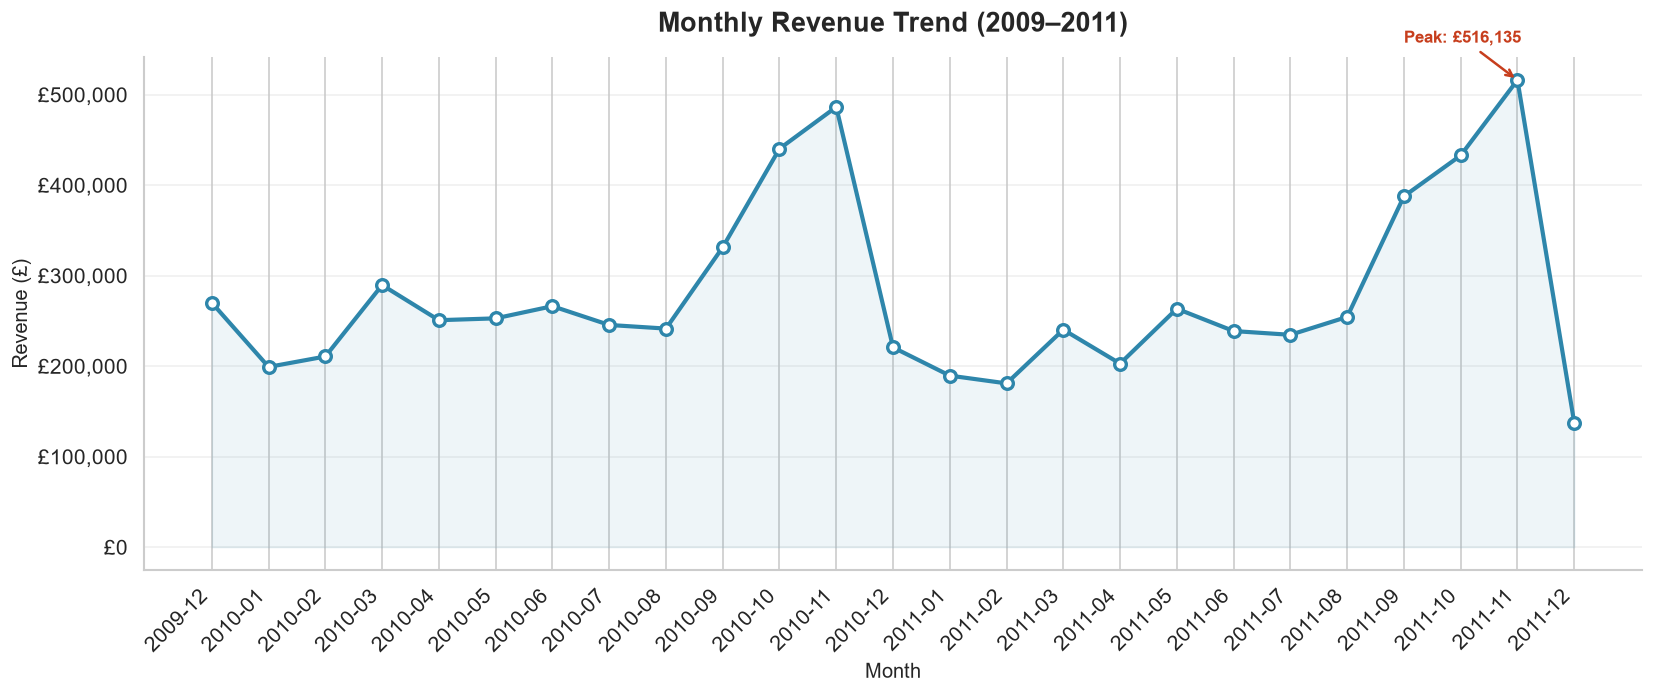

In [14]:
# ── Viz 1: Monthly Revenue Trend (Line Chart) ───────────────────
monthly_rev = df.groupby('InvoiceMonth')['Revenue'].sum().reset_index()
monthly_rev['InvoiceMonth'] = monthly_rev['InvoiceMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_rev['InvoiceMonth'], monthly_rev['Revenue'],
        color=PALETTE[0], linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor=PALETTE[0])

# Highlight peak month
peak_idx = monthly_rev['Revenue'].idxmax()
ax.annotate(f"Peak: £{monthly_rev.loc[peak_idx, 'Revenue']:,.0f}",
            xy=(peak_idx, monthly_rev.loc[peak_idx, 'Revenue']),
            xytext=(peak_idx - 2, monthly_rev.loc[peak_idx, 'Revenue'] * 1.08),
            fontsize=10, fontweight='bold', color=PALETTE[3],
            arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.5))

ax.fill_between(range(len(monthly_rev)), monthly_rev['Revenue'],
                alpha=0.08, color=PALETTE[0])
ax.set_title('Monthly Revenue Trend (2009–2011)', fontsize=16, pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/01_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 🏆 3.2 Top 10 Products by Revenue

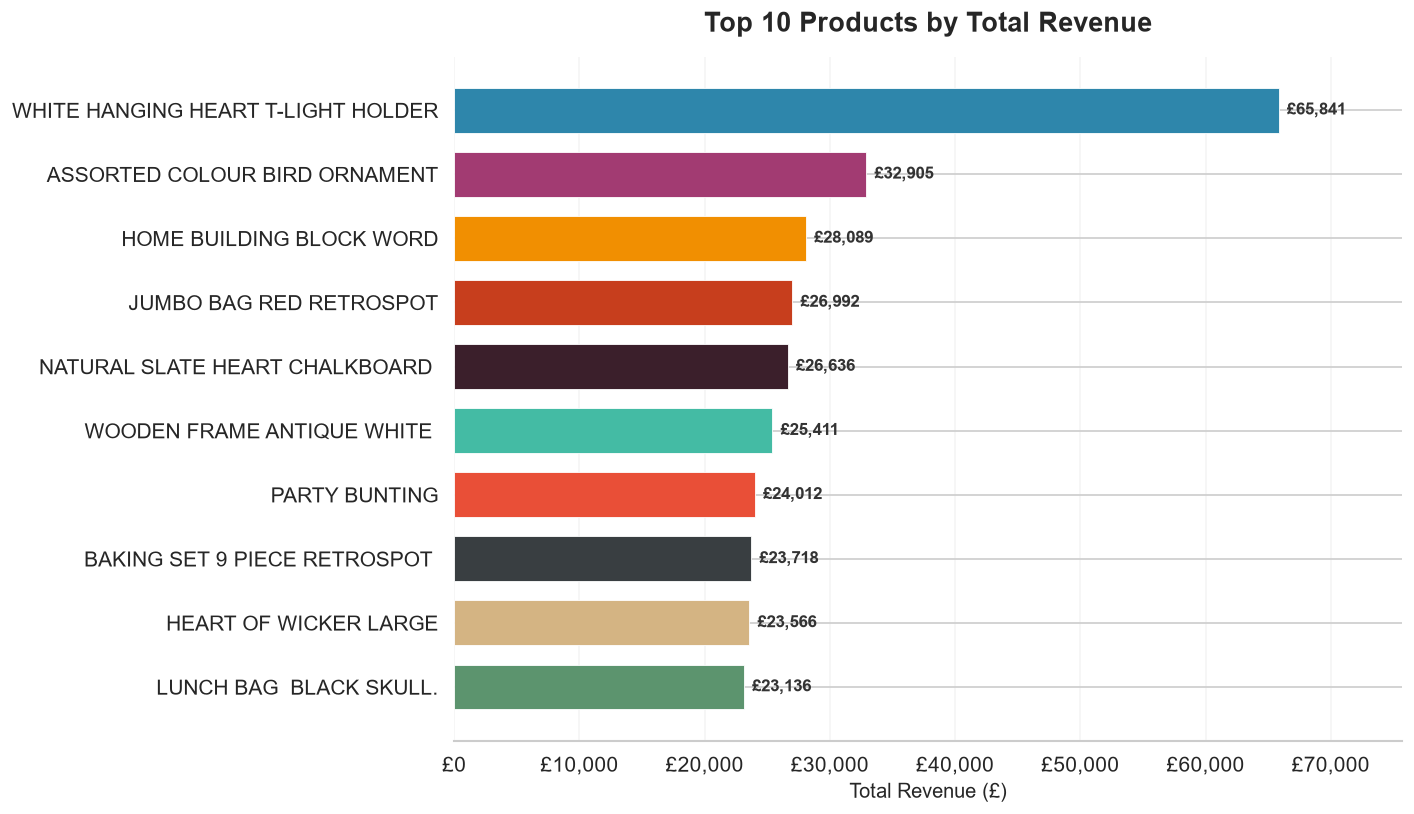

In [15]:
# ── Viz 2: Top 10 Products by Revenue (Horizontal Bar) ──────────
product_rev = (df.groupby('Description')['Revenue']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .sort_values())

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(product_rev.index, product_rev.values, 
               color=PALETTE[:10][::-1], edgecolor='white', linewidth=0.5, height=0.7)

# Add value labels
for bar, val in zip(bars, product_rev.values):
    ax.text(val + product_rev.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=10, fontweight='bold', color='#333')

ax.set_title('Top 10 Products by Total Revenue', fontsize=16, pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xlim(0, product_rev.max() * 1.15)
sns.despine(left=True)
ax.tick_params(left=False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/02_top10_products_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 🌍 3.3 Sales by Country × Month Heatmap

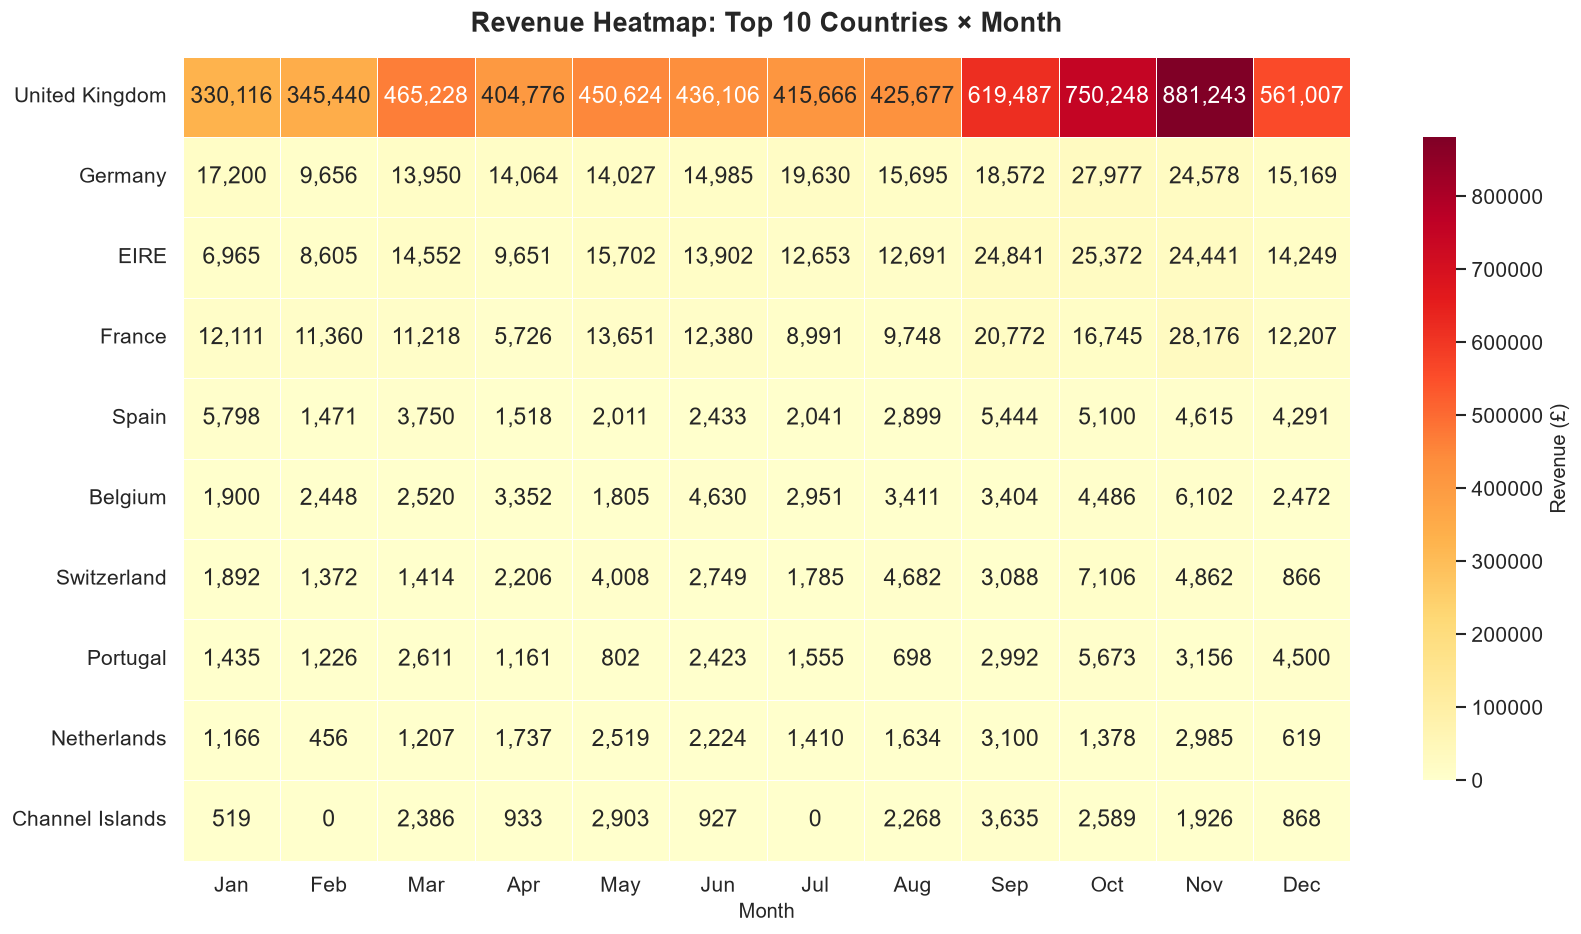

In [16]:
# ── Viz 3: Sales by Country Heatmap (Top 10 Countries × Months) ─
# Get top 10 countries by revenue (excluding UK for better contrast)
top_countries = (df.groupby('Country')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .index.tolist())

df_top_countries = df[df['Country'].isin(top_countries)]
heatmap_data = (df_top_countries.groupby(['Country', 'Month'])['Revenue']
                .sum()
                .unstack(fill_value=0))

# Reorder by total revenue
country_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[country_order]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Revenue (£)', 'shrink': 0.8},
            ax=ax)
ax.set_title('Revenue Heatmap: Top 10 Countries × Month', fontsize=16, pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.savefig('../outputs/03_country_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 3.4 Order Quantity Distribution

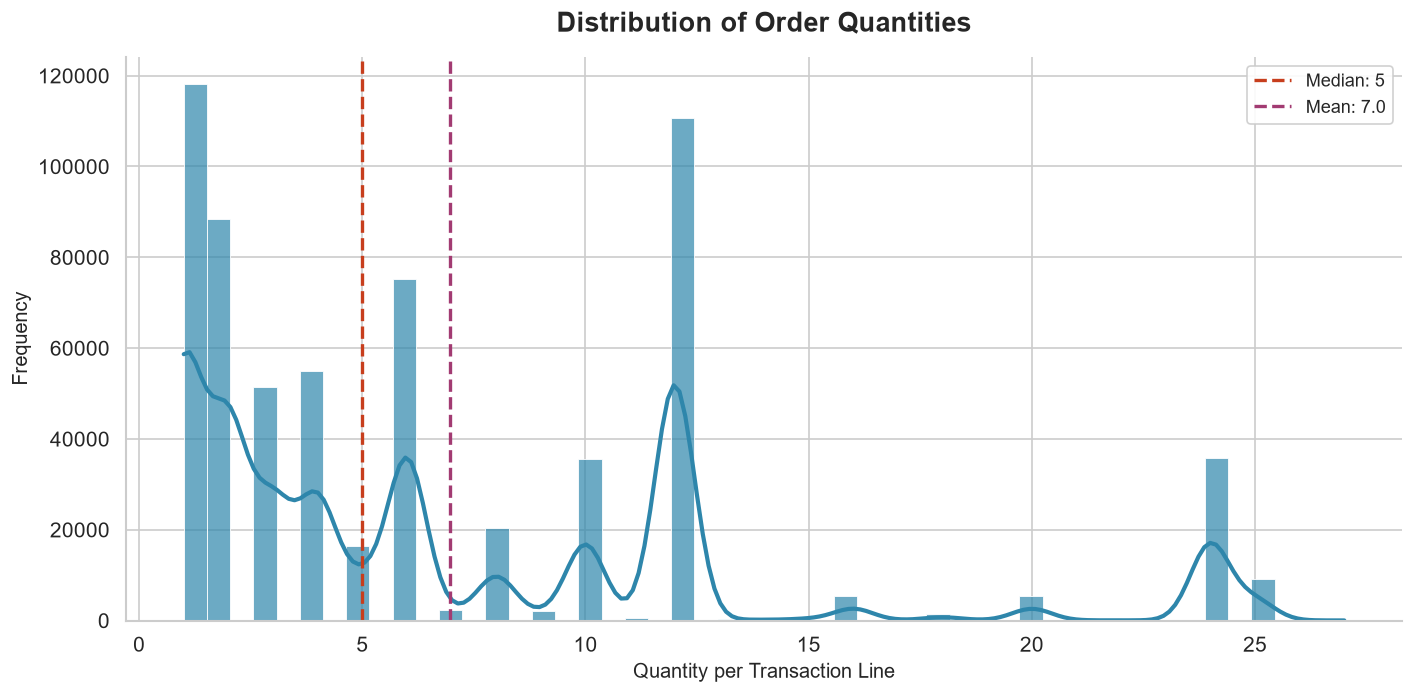

Quantity Stats — Mean: 7.0, Median: 5, Std: 6.4, Skewness: 1.34


In [17]:
# ── Viz 4: Order Quantity Distribution (Histogram + KDE) ─────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(df['Quantity'], bins=50, kde=True, color=PALETTE[0],
             edgecolor='white', linewidth=0.5, alpha=0.7,
             line_kws={'linewidth': 2.5}, ax=ax)

# Add statistical annotations
median_qty = df['Quantity'].median()
mean_qty = df['Quantity'].mean()
ax.axvline(median_qty, color=PALETTE[3], linestyle='--', linewidth=2, label=f'Median: {median_qty:.0f}')
ax.axvline(mean_qty, color=PALETTE[1], linestyle='--', linewidth=2, label=f'Mean: {mean_qty:.1f}')

ax.set_title('Distribution of Order Quantities', fontsize=16, pad=15)
ax.set_xlabel('Quantity per Transaction Line', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/04_quantity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Quantity Stats — Mean: {mean_qty:.1f}, Median: {median_qty:.0f}, "
      f"Std: {df['Quantity'].std():.1f}, Skewness: {df['Quantity'].skew():.2f}")

### 🔗 3.5 Correlation Matrix

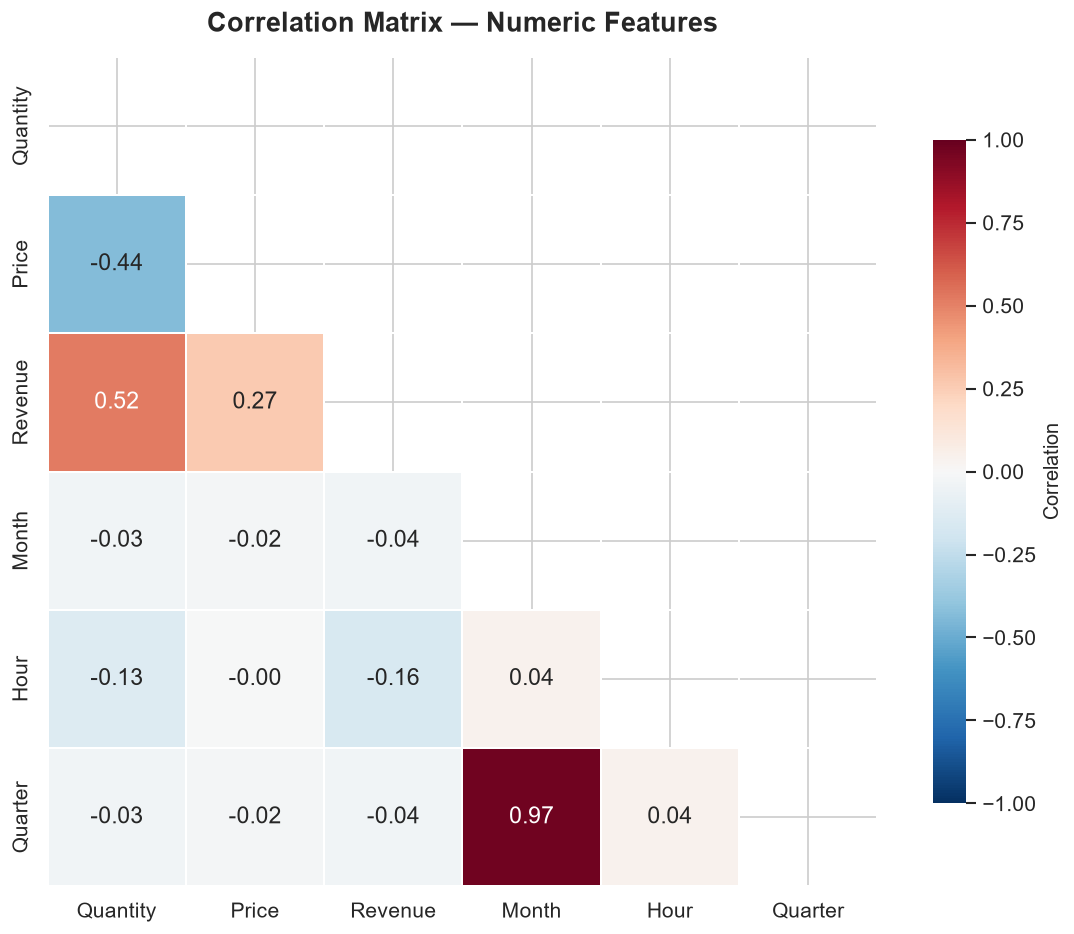

In [18]:
# ── Viz 5: Correlation Matrix (Numeric Features) ────────────────
numeric_cols = ['Quantity', 'Price', 'Revenue', 'Month', 'Hour', 'Quarter']
corr_matrix = df[numeric_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig('../outputs/05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 📅 3.6 Revenue by Day of Week

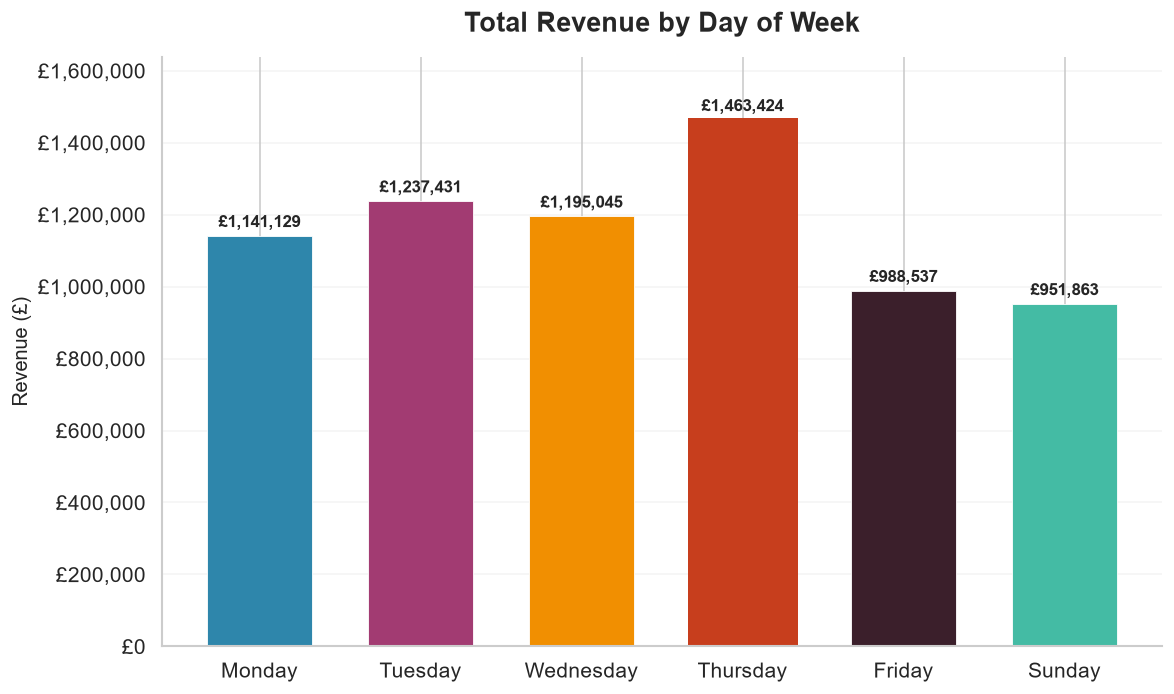

In [19]:
# ── Viz 6: Revenue by Day of Week ────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_rev = (df.groupby('DayOfWeek')['Revenue']
           .sum()
           .reindex(day_order)
           .dropna())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(day_rev.index, day_rev.values, color=PALETTE[:len(day_rev)],
              edgecolor='white', linewidth=0.5, width=0.65)

# Highlight the peak day
peak_day = day_rev.idxmax()
peak_idx_bar = list(day_rev.index).index(peak_day)
bars[peak_idx_bar].set_edgecolor(PALETTE[3])
bars[peak_idx_bar].set_linewidth(3)

for bar, val in zip(bars, day_rev.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + day_rev.max() * 0.01,
            f'£{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Total Revenue by Day of Week', fontsize=16, pad=15)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_ylim(0, day_rev.max() * 1.12)
sns.despine()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/06_revenue_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### 👥 3.7 Top 10 Customers by Revenue

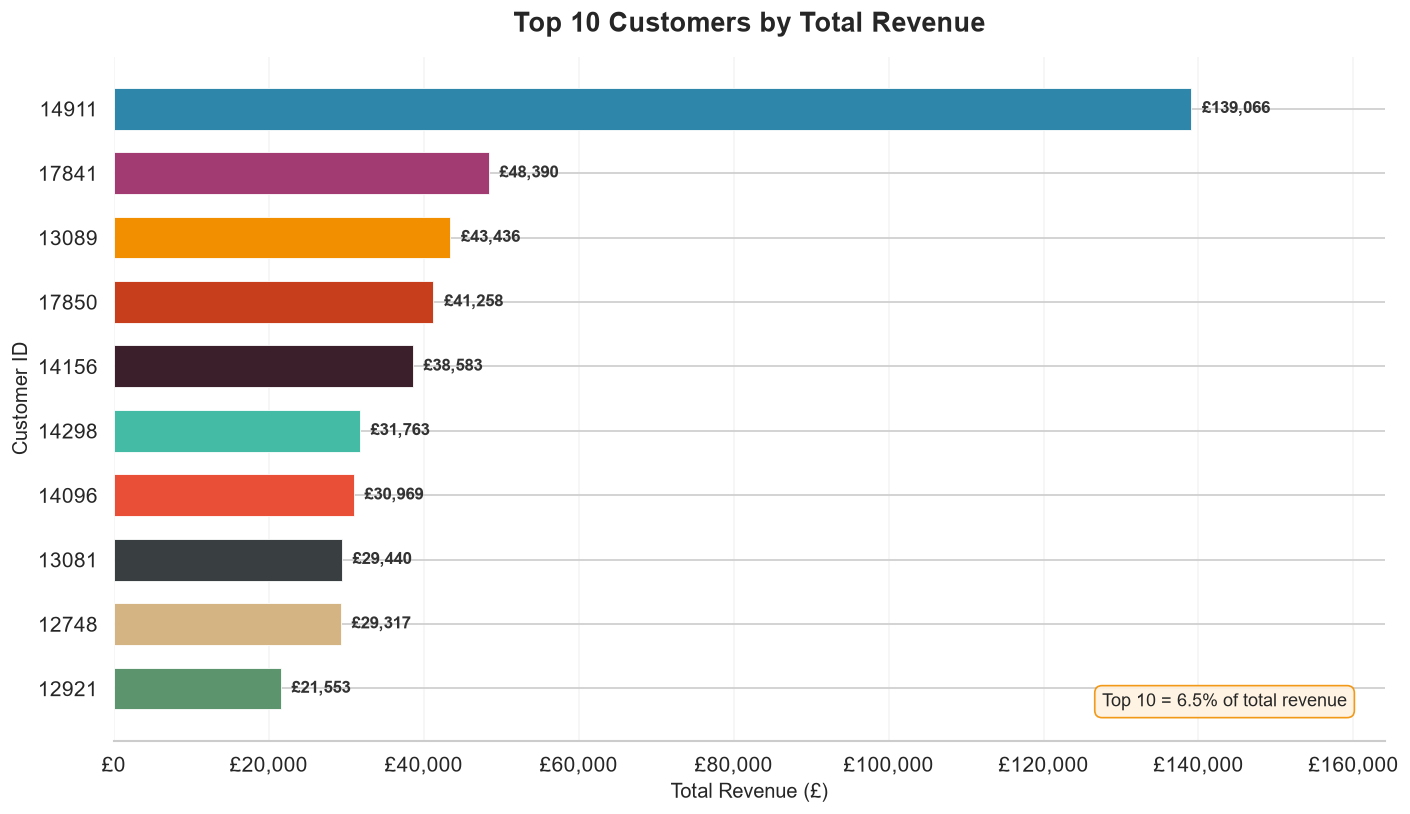

In [20]:
# ── Viz 7: Top 10 Customers by Revenue ───────────────────────────
customer_rev = (df.groupby('Customer ID')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .sort_values())

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(customer_rev.index, customer_rev.values,
               color=PALETTE[:10][::-1], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, customer_rev.values):
    ax.text(val + customer_rev.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=10, fontweight='bold', color='#333')

# Pareto annotation
total_rev = df['Revenue'].sum()
top10_rev = customer_rev.sum()
ax.text(0.97, 0.05, f'Top 10 = {top10_rev/total_rev*100:.1f}% of total revenue',
        transform=ax.transAxes, ha='right', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#F18F01', alpha=0.9))

ax.set_title('Top 10 Customers by Total Revenue', fontsize=16, pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.set_ylabel('Customer ID', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xlim(0, customer_rev.max() * 1.18)
sns.despine(left=True)
ax.tick_params(left=False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/07_top10_customers.png', dpi=150, bbox_inches='tight')
plt.show()

### ⏰ 3.8 Hourly Order Volume

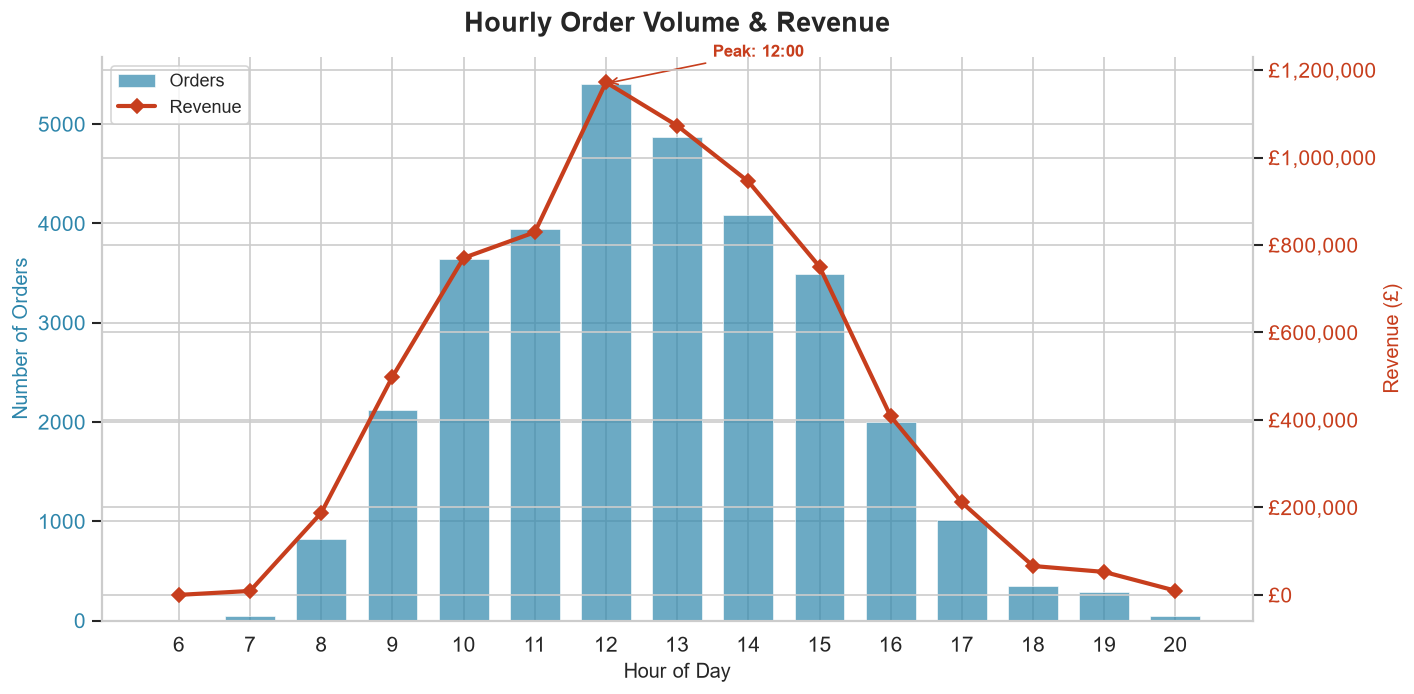

In [21]:
# ── Viz 8: Hourly Order Volume ───────────────────────────────────
hourly = df.groupby('Hour').agg(
    Orders=('Invoice', 'nunique'),
    Revenue=('Revenue', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for order count
bars = ax1.bar(hourly['Hour'], hourly['Orders'], color=PALETTE[0],
               alpha=0.7, edgecolor='white', linewidth=0.5, width=0.7, label='Orders')
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12, color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

# Line chart for revenue on secondary axis
ax2 = ax1.twinx()
ax2.plot(hourly['Hour'], hourly['Revenue'], color=PALETTE[3],
         linewidth=2.5, marker='D', markersize=6, label='Revenue')
ax2.set_ylabel('Revenue (£)', fontsize=12, color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Peak hour annotation
peak_hour = hourly.loc[hourly['Orders'].idxmax(), 'Hour']
ax1.annotate(f'Peak: {peak_hour}:00', xy=(peak_hour, hourly['Orders'].max()),
             xytext=(peak_hour + 1.5, hourly['Orders'].max() * 1.05),
             fontsize=10, fontweight='bold', color=PALETTE[3],
             arrowprops=dict(arrowstyle='->', color=PALETTE[3]))

ax1.set_xticks(range(int(hourly['Hour'].min()), int(hourly['Hour'].max()) + 1))
ax1.set_title('Hourly Order Volume & Revenue', fontsize=16, pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../outputs/08_hourly_orders.png', dpi=150, bbox_inches='tight')
plt.show()

### 📦 3.9 Revenue Distribution by Quarter

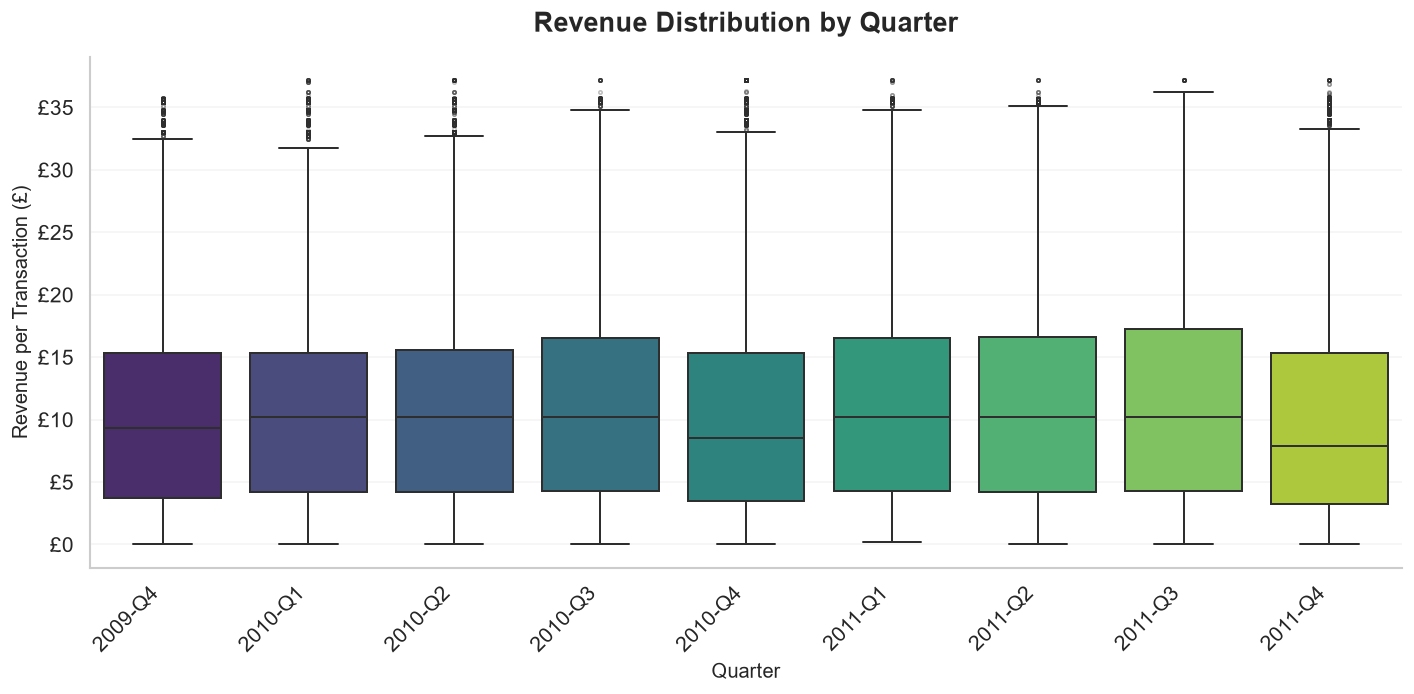

In [22]:
# ── Viz 9: Revenue Distribution by Quarter (Box Plot) ────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Create quarter labels in order
quarter_order = sorted(df['YearQuarter'].unique())

bp = sns.boxplot(x='YearQuarter', y='Revenue', data=df,
                 order=quarter_order, palette='viridis',
                 fliersize=2, flierprops=dict(alpha=0.3),
                 linewidth=1.2, ax=ax)

ax.set_title('Revenue Distribution by Quarter', fontsize=16, pad=15)
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Revenue per Transaction (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
sns.despine()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/09_revenue_boxplot_quarter.png', dpi=150, bbox_inches='tight')
plt.show()

### 👤 3.10 Monthly Unique Customer Count Trend

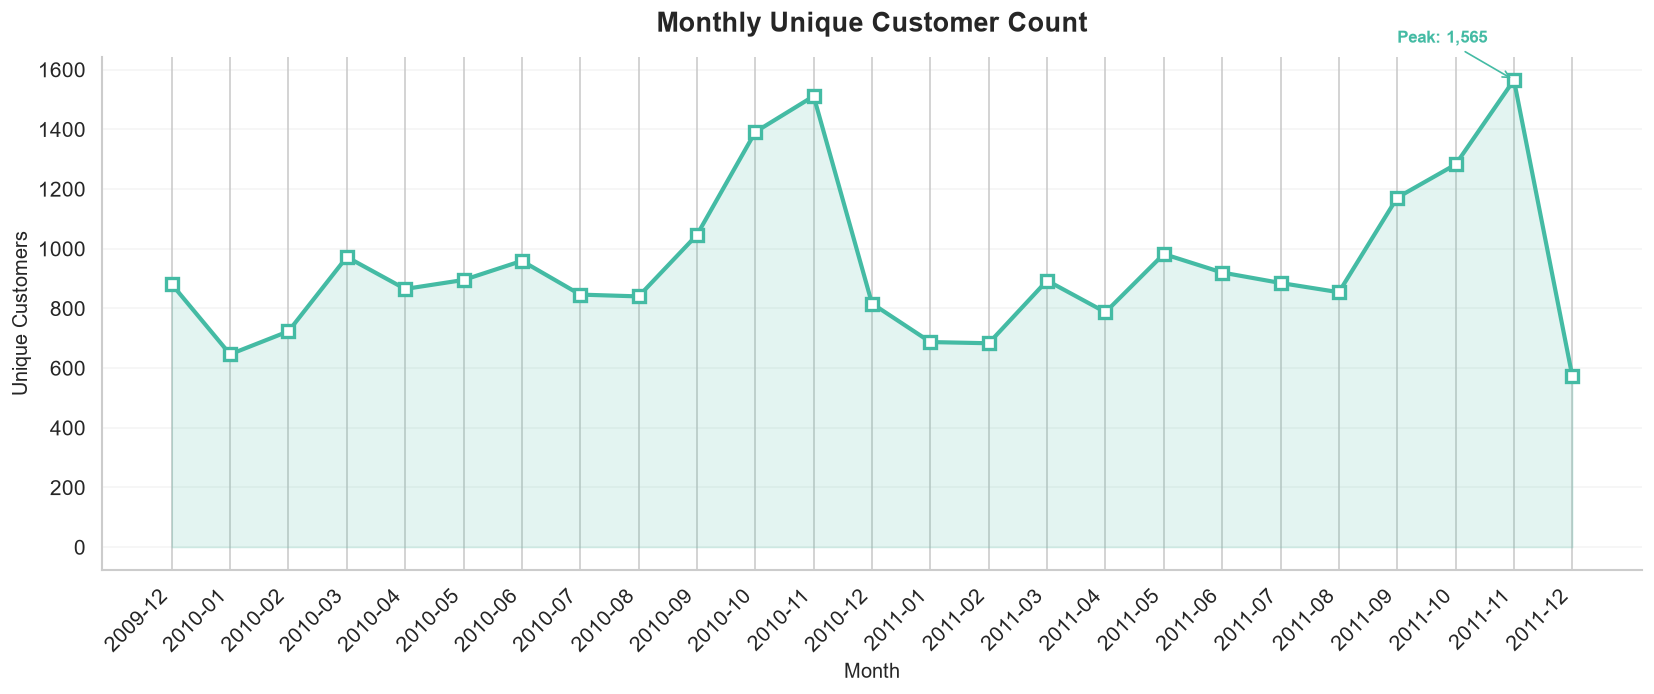

In [23]:
# ── Viz 10: Monthly Unique Customer Count ────────────────────────
monthly_cust = (df.groupby('InvoiceMonth')['Customer ID']
                .nunique()
                .reset_index()
                .rename(columns={'Customer ID': 'UniqueCustomers'}))
monthly_cust['InvoiceMonth'] = monthly_cust['InvoiceMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(range(len(monthly_cust)), monthly_cust['UniqueCustomers'],
                alpha=0.15, color=PALETTE[5])
ax.plot(monthly_cust['InvoiceMonth'], monthly_cust['UniqueCustomers'],
        color=PALETTE[5], linewidth=2.5, marker='s', markersize=7,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor=PALETTE[5])

# Annotate max & min
max_idx = monthly_cust['UniqueCustomers'].idxmax()
min_idx = monthly_cust['UniqueCustomers'].idxmin()

ax.annotate(f"Peak: {monthly_cust.loc[max_idx, 'UniqueCustomers']:,}",
            xy=(max_idx, monthly_cust.loc[max_idx, 'UniqueCustomers']),
            xytext=(max_idx - 2, monthly_cust.loc[max_idx, 'UniqueCustomers'] * 1.08),
            fontsize=10, fontweight='bold', color=PALETTE[5],
            arrowprops=dict(arrowstyle='->', color=PALETTE[5]))

ax.set_title('Monthly Unique Customer Count', fontsize=16, pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Unique Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/10_monthly_customers.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Business Insights

Data-driven conclusions derived from the exploratory analysis above.

In [24]:
# ── Insight Calculations ─────────────────────────────────────────

# 1. Q4 Revenue Concentration
q4_rev = df[df['Quarter'] == 4]['Revenue'].sum()
annual_rev = df['Revenue'].sum()
q4_pct = q4_rev / annual_rev * 100

# 2. Customer Concentration (Pareto)
cust_rev = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
total_customers = len(cust_rev)
top_20_pct_count = int(total_customers * 0.20)
top_20_pct_rev = cust_rev.head(top_20_pct_count).sum() / annual_rev * 100

# 3. Geographic Dependency
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
uk_pct = country_rev.get('United Kingdom', 0) / annual_rev * 100
top3_countries = country_rev.head(3)

# 4. Peak Trading Time
peak_day_name = (df.groupby('DayOfWeek')['Revenue'].sum()
                 .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
                 .dropna().idxmax())
peak_hour_val = df.groupby('Hour')['Revenue'].sum().idxmax()

# 5. Product Concentration
product_rev_all = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_10_products_pct = product_rev_all.head(10).sum() / annual_rev * 100
total_products = len(product_rev_all)

print("✅ Insight calculations complete — see markdown below.")

✅ Insight calculations complete — see markdown below.


In [25]:
# ── Print Business Insights ──────────────────────────────────────
print("=" * 65)
print("📊 BUSINESS INSIGHTS")
print("=" * 65)

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 1: Q4 Seasonality Drives Disproportionate Revenue
   Q4 accounts for {q4_pct:.1f}% of total revenue.
   November alone typically sees the highest monthly sales,
   driven by pre-Christmas gifting. 
   → Recommendation: Increase inventory and marketing spend
     by 40-50% in September to prepare for Q4 demand surge.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 2: Severe Customer Concentration Risk
   Top 20% of customers generate {top_20_pct_rev:.1f}% of revenue.
   Total customer base: {total_customers:,} unique customers.
   → Recommendation: Implement a loyalty/retention program for 
     top-tier customers while diversifying the revenue base
     through acquisition campaigns.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 3: Heavy Geographic Revenue Dependency
   United Kingdom: {uk_pct:.1f}% of total revenue.
   Top 3 markets outside UK: {', '.join(top3_countries.index[1:4]) if len(top3_countries) > 1 else 'N/A'}
   → Recommendation: Accelerate international expansion in 
     top-performing EU markets (DACH region, Netherlands, France)
     to reduce single-market risk.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 4: Clear Peak Trading Windows
   Peak day: {peak_day_name}
   Peak hour: {peak_hour_val}:00
   → Recommendation: Schedule promotions, email campaigns, and 
     flash sales during peak windows to maximize conversion.
     Ensure customer support staffing aligns with peak hours.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 5: Long-Tail Product Portfolio
   Top 10 products generate {top_10_products_pct:.1f}% of revenue
   out of {total_products:,} total products.
   → Recommendation: Focus marketing on proven bestsellers while
     evaluating low-performing SKUs for discontinuation to reduce
     warehousing costs and inventory complexity.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

📊 BUSINESS INSIGHTS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 1: Q4 Seasonality Drives Disproportionate Revenue
   Q4 accounts for 35.9% of total revenue.
   November alone typically sees the highest monthly sales,
   driven by pre-Christmas gifting. 
   → Recommendation: Increase inventory and marketing spend
     by 40-50% in September to prepare for Q4 demand surge.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 2: Severe Customer Concentration Risk
   Top 20% of customers generate 67.8% of revenue.
   Total customer base: 5,611 unique customers.
   → Recommendation: Implement a loyalty/retention program for 
     top-tier customers while diversifying the revenue base
     through acquisition campaigns.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 INSIGHT 3: Heavy Geographic Revenue Dependency
   United Kingdom: 87.1% of total revenue.
   Top 3 markets outside UK: Germany, EIRE
   → Recommendation:

---

## 5. Summary & Next Steps

### What We Accomplished
| Step | Detail |
|------|--------|
| **Data Cleaning** | Handled missing values, duplicates, cancelled orders, type casting, datetime parsing, and IQR-based outlier removal |
| **Feature Engineering** | Created Revenue, time-based features (Year, Month, Day, Hour, Quarter) |
| **Visualizations** | 10 publication-ready charts covering trends, distributions, correlations, and geographic patterns |
| **Business Insights** | 5 data-backed, actionable conclusions with strategic recommendations |

### Recommended Next Steps
1. **Customer Segmentation** — Apply RFM (Recency, Frequency, Monetary) analysis for targeted marketing
2. **Demand Forecasting** — Use time-series models (ARIMA/Prophet) to predict monthly revenue
3. **Market Basket Analysis** — Identify product bundles using association rules
4. **Churn Prediction** — Build a classification model to identify at-risk customers
5. **Interactive Dashboard** — Deploy a Plotly/Dash dashboard for real-time monitoring

---

*Notebook by [Your Name] | Data source: [UCI ML Repository — Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)*